# 1. Imports and setup.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import time
import warnings
warnings.filterwarnings('ignore')

# Clustering & dimensionality reduction
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.neighbors import LocalOutlierFactor
from scipy.cluster.hierarchy import dendrogram, linkage

# Association rules
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, fpgrowth, association_rules

# Plot style
plt.rcParams.update({'figure.dpi': 100, 'axes.spines.top': False,
                     'axes.spines.right': False, 'font.size': 11})

print('All packages imported successfully')

All packages imported successfully


# 2. Data Loading.

In [2]:
from ucimlrepo import fetch_ucirepo

online_retail = fetch_ucirepo(id=352)
df = online_retail.data.original
print(f'Raw dataset: {df.shape[0]:,} rows, {df.shape[1]} columns')
df.head()

Raw dataset: 541,909 rows, 8 columns


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


# 3. Visualizing Raw Data.

# 4. Data Cleaning and Preprocessing.

In [5]:
# 1. Remove cancellations (InvoiceNo starts with 'C')
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

# 2. UK-only
df = df[df['Country'] == 'United Kingdom']

# 3. Positive quantities only
df = df[df['Quantity'] > 0]

# 4. Non-null, non-empty descriptions
df = df[~(df['Description'].isna() | (df['Description'].str.strip() == ''))]

# 5. Positive unit prices only
df = df[df['UnitPrice'] > 0]

# 6. Parse dates and derived columns
df['InvoiceDate']  = pd.to_datetime(df['InvoiceDate'])
df['InvoiceMonth'] = df['InvoiceDate'].dt.to_period('M')
df['Month']        = df['InvoiceDate'].dt.month
df['TotalPrice']   = df['Quantity'] * df['UnitPrice']

print(f'Clean dataset: {df.shape[0]:,} rows')
print(f'Date range:    {df["InvoiceDate"].min().date()} — {df["InvoiceDate"].max().date()}')
print(f'Invoices: {df["InvoiceNo"].nunique():,}\n  '
      f'Customers (with ID): {df["CustomerID"].nunique():,}\n  '
      f'Unique products: {df["StockCode"].nunique():,}')

Clean dataset: 485,123 rows
Date range:    2010-12-01 — 2011-12-09

Invoices: 18,019
  Customers (with ID): 3,920
  Unique products: 3,916


# 5. Association Rule Mining — Apriori vs FP-Growth
Both algorithms are run on the same basket matrix with identical thresholds, allowing a direct comparison of runtime and rule output.
**Threshold justification:**
- `min_support = 0.01` (1% of invoices). At 0.02 only 5 rules survived. At 0.01, 177 rules emerged across three distinct product families. At 0.005, >2,000 rules with many trivial patterns.
- `min_confidence = 0.80`: Each rule predicts its consequent in at least 80% of qualifying transactions.

In [6]:
# Build basket matrix (one row per invoice)
baskets = (df.groupby('InvoiceNo')['Description']
             .apply(list)
             .reset_index(name='items'))
transactions = baskets['items'].tolist()

te = TransactionEncoder()
# Cast columns to plain str — avoids mlxtend/numpy string-type incompatibility
basket_matrix = pd.DataFrame(
    te.fit(transactions).transform(transactions),
    columns=[str(c) for c in te.columns_]
)
print(f'Basket matrix: {basket_matrix.shape[0]:,} invoices × {basket_matrix.shape[1]:,} products')

Basket matrix: 18,019 invoices × 4,007 products


In [8]:
# Apriori
t0 = time.perf_counter()
fi_apriori = apriori(basket_matrix, min_support=0.01, use_colnames=True)
ir_apriori = association_rules(fi_apriori, metric='confidence', min_threshold=0.80)
t_apriori  = time.perf_counter() - t0

# FP-Growth
t0 = time.perf_counter()
fi_fp = fpgrowth(basket_matrix, min_support=0.01, use_colnames=True)
ir_fp = association_rules(fi_fp, metric='confidence', min_threshold=0.80)
t_fp  = time.perf_counter() - t0

# ── Comparison table
comparison = pd.DataFrame({
    'Algorithm':      ['Apriori', 'FP-Growth'],
    'Frequent itemsets': [len(fi_apriori), len(fi_fp)],
    'Rules generated':   [len(ir_apriori), len(ir_fp)],
    'Runtime (s)':       [round(t_apriori, 3), round(t_fp, 3)],
    'Speedup':           ['1.0×', f'{t_apriori/t_fp:.1f}×'],
})
print('=== Algorithm Comparison ===')
print(comparison.to_string(index=False))
print(f'\nRule sets identical: {len(ir_apriori) == len(ir_fp)}')

=== Algorithm Comparison ===
Algorithm  Frequent itemsets  Rules generated  Runtime (s) Speedup
  Apriori               2156              177      152.099    1.0×
FP-Growth               2156              177        8.726   17.4×

Rule sets identical: True


In [9]:
# Top rules by lift
item_rules = ir_apriori.copy()   # use Apriori output for remainder
item_rules.sort_values('lift', ascending=False)[
    ['antecedents', 'consequents', 'support', 'confidence', 'lift']
].head(10)

,antecedents,consequents,support,confidence,lift
120,frozenset({HERB MARKER THYME}),"frozenset({HERB MARKER ROSEMARY, HERB MARKER P...",0.010933,0.856522,74.558769
115,"frozenset({HERB MARKER ROSEMARY, HERB MARKER P...",frozenset({HERB MARKER THYME}),0.010933,0.951691,74.558769
110,"frozenset({HERB MARKER MINT, HERB MARKER THYME})",frozenset({HERB MARKER ROSEMARY}),0.010600,0.955000,74.494134
113,frozenset({HERB MARKER ROSEMARY}),"frozenset({HERB MARKER MINT, HERB MARKER THYME})",0.010600,0.826840,74.494134
107,frozenset({HERB MARKER PARSLEY}),"frozenset({HERB MARKER MINT, HERB MARKER THYME})",0.010433,0.824561,74.288860
104,"frozenset({HERB MARKER MINT, HERB MARKER THYME})",frozenset({HERB MARKER PARSLEY}),0.010433,0.940000,74.288860
117,"frozenset({HERB MARKER PARSLEY, HERB MARKER TH...",frozenset({HERB MARKER ROSEMARY}),0.010933,0.951691,74.236004
118,frozenset({HERB MARKER ROSEMARY}),"frozenset({HERB MARKER PARSLEY, HERB MARKER TH...",0.010933,0.852814,74.236004
94,frozenset({HERB MARKER ROSEMARY}),"frozenset({HERB MARKER BASIL, HERB MARKER THYME})",0.010711,0.835498,74.161751
93,"frozenset({HERB MARKER BASIL, HERB MARKER THYME})",frozenset({HERB MARKER ROSEMARY}),0.010711,0.950739,74.161751


In [10]:
# clustering rules into product families.
def has_kw(itemset, kw):
    return any(kw.upper() in str(i).upper() for i in itemset)

herb_r   = item_rules[item_rules['antecedents'].apply(lambda x: has_kw(x,'HERB'))]
teacup_r = item_rules[item_rules['antecedents'].apply(
    lambda x: has_kw(x,'REGENCY') or has_kw(x,'TEACUP'))]
jumbo_r  = item_rules[item_rules['antecedents'].apply(lambda x: has_kw(x,'JUMBO'))]
other_r  = item_rules.drop(index=herb_r.index.union(teacup_r.index).union(jumbo_r.index))

families = pd.DataFrame({
    'Product Family': ['Herb Markers','Regency Teacup Set','Jumbo Bag Collection','Other'],
    'Rules':   [len(herb_r), len(teacup_r), len(jumbo_r), len(other_r)],
    'Avg Lift': [herb_r['lift'].mean(), teacup_r['lift'].mean(),
                  jumbo_r['lift'].mean(), other_r['lift'].mean() if len(other_r) else 0],
    'Avg Confidence': [herb_r['confidence'].mean(), teacup_r['confidence'].mean(),
                        jumbo_r['confidence'].mean(), other_r['confidence'].mean() if len(other_r) else 0],
}).round(3)
print(families.to_string(index=False))

      Product Family  Rules  Avg Lift  Avg Confidence
        Herb Markers     81    71.235           0.879
  Regency Teacup Set     20    26.752           0.876
Jumbo Bag Collection     38    10.173           0.837
               Other     40    21.964           0.853


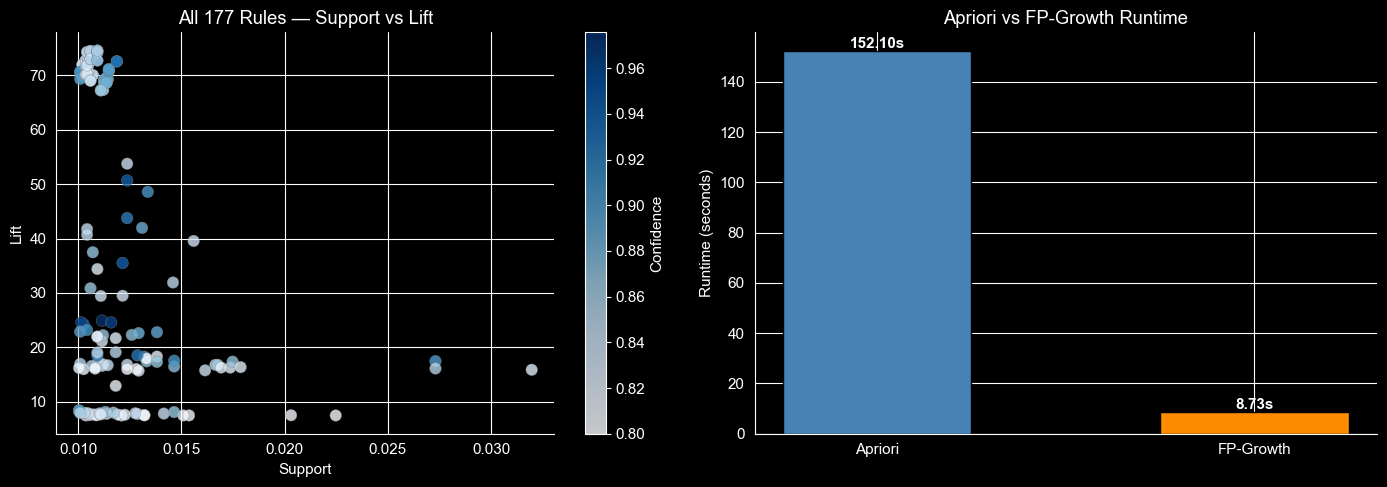

In [11]:
#figures showing findings from running the two algorithms.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Support vs Lift, colored by confidence
sc = axes[0].scatter(item_rules['support'], item_rules['lift'],
                     c=item_rules['confidence'], cmap='Blues',
                     alpha=0.8, edgecolors='grey', linewidths=0.3, s=70)
plt.colorbar(sc, ax=axes[0], label='Confidence')
axes[0].set_xlabel('Support')
axes[0].set_ylabel('Lift')
axes[0].set_title(f'All {len(item_rules)} Rules — Support vs Lift')

# Right: Apriori vs FP-Growth runtime bar
axes[1].bar(['Apriori', 'FP-Growth'], [t_apriori, t_fp],
            color=['steelblue', 'darkorange'], edgecolor='black', width=0.5)
axes[1].set_ylabel('Runtime (seconds)')
axes[1].set_title('Apriori vs FP-Growth Runtime')
for i, v in enumerate([t_apriori, t_fp]):
    axes[1].text(i, v + 0.02, f'{v:.2f}s', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

In [12]:
# effect of threshold choice; justifying the threshold choice for both algorithms.
frequent_itemsets2 = apriori(basket_matrix, min_support=0.02, use_colnames=True)
item_rules2 = association_rules(frequent_itemsets2, metric='confidence', min_threshold=0.80)
print(f'At min_support=0.02: {len(item_rules2)} rules')
print(f'At min_support=0.01: {len(item_rules)} rules')
print('\nAll rules at min_support=0.02:')
item_rules2.sort_values('lift', ascending=False)[
    ['antecedents','consequents','support','confidence','lift']
]

At min_support=0.02: 5 rules
At min_support=0.01: 177 rules

All rules at min_support=0.02:


,antecedents,consequents,support,confidence,lift
1,"frozenset({ROSES REGENCY TEACUP AND SAUCER , P...",frozenset({GREEN REGENCY TEACUP AND SAUCER}),0.027305,0.902752,17.453534
2,"frozenset({PINK REGENCY TEACUP AND SAUCER, GRE...",frozenset({ROSES REGENCY TEACUP AND SAUCER }),0.027305,0.854167,16.099612
0,frozenset({PINK REGENCY TEACUP AND SAUCER}),frozenset({GREEN REGENCY TEACUP AND SAUCER}),0.031966,0.820513,15.863541
3,"frozenset({JUMBO BAG PINK POLKADOT, JUMBO SHOP...",frozenset({JUMBO BAG RED RETROSPOT}),0.020312,0.806167,7.507147
4,"frozenset({JUMBO BAG PINK POLKADOT, JUMBO STOR...",frozenset({JUMBO BAG RED RETROSPOT}),0.022476,0.801980,7.468156


# 6. RFM Feature Engineering
RFM reduces each customer to three interpretable behavioral dimensions:
- **Recency** — days since last purchase (lower = more recent)
- **Frequency** — number of distinct invoices
- **Monetary** — total spend in GBP

Only rows with a valid CustomerID are used for customer-level analysis.
